# Tutorial 3b: Choosing a Method

Optiland's `minimize()` function supports a broad family of optimization algorithms. Picking the right one can make the difference between a fast convergence and an hour-long run that ends in a local minimum.

This tutorial covers:

* The two entry points (`minimize()` vs. your own loop)
* Method families and their intended use cases
* `tol` semantics — how tolerance is interpreted differently per family
* A side-by-side comparison of `'dls'` and `'l-bfgs-b'` on the same doublet
* A decision guide to help you choose

## 1. Imports

In [1]:
import copy
import numpy as np

from optiland import optic, analysis
from optiland.optimization import OptimizationProblem, minimize

## 2. The two entry points

### `minimize()` — Optiland owns the loop

```python
result = minimize(problem, method='dls')
```

Optiland constructs the optimizer, runs the iteration loop, and returns when a stopping criterion is satisfied. This is the recommended approach for the vast majority of lens design tasks.

### Custom loop — you own the loop

For research workflows where you need to inject logic *between* iterations (e.g., swap operands, adjust weights, log to a database), you can drive the optimizer directly. See **Tutorial 3e** for that pattern. Everything in this tutorial assumes you are using `minimize()`.

## 3. Method families

| Family | `method=` strings | When to use | Backend |
|--------|-------------------|-------------|----------|
| **Native DLS/LM** | `'dls'`, `'lm'` | Classical lens design; equality targets; over-determined residual problems (m ≥ n) | NumPy + Torch |
| **Gauss-Newton** | `'gauss_newton'` | Close to a good solution; no damping needed | NumPy + Torch |
| **Torch first-order** | `'adam'`, `'sgd'` | GPU-resident differentiable pipelines; large parameter counts | Torch only |
| **SciPy local (gradient)** | `'l-bfgs-b'`, `'slsqp'`, `'trust-constr'`, `'cobyla'` | Bound- or inequality-constraint-dominated; scalar merit | NumPy |
| **SciPy least-squares** | `'least_squares'` | Trust-region residual; alternative to DLS | NumPy |
| **SciPy global** | `'differential_evolution'`, `'dual_annealing'`, `'shgo'`, `'basin_hopping'` | Global search; no gradient information; wide search basin | NumPy |
| **Auto** | `'auto'` *(default)* | Let Optiland decide based on problem structure | NumPy or Torch |

> **Tip:** `'dls'` is the workhorse for classical lens design. Start here unless you have a specific reason to use another family.

## 4. `tol` semantics

The `tol` keyword passed to `minimize()` is interpreted differently depending on the method family:

| Family | `tol` maps to | Meaning |
|--------|---------------|---------|
| DLS / Gauss-Newton | `CostTolerance` | Stop when relative merit change per iteration < tol |
| Torch (`adam`, `sgd`) | `GradNormTolerance` | Stop when L2 norm of gradient < tol |
| SciPy methods | forwarded to SciPy | Interpreted by the underlying SciPy routine |

You can replace the default stopping criterion entirely by passing a custom `stop=` argument — see Tutorial 3c.

## 5. Build the reference doublet

We build an achromatic doublet (crown + flint cemented pair) as our test system. The starting values are deliberately un-optimized so both methods have real work to do.

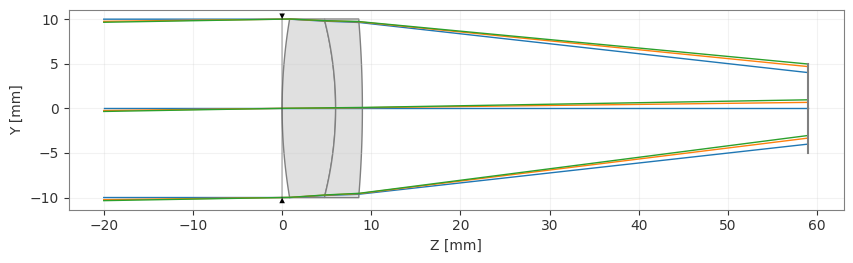

In [2]:
def build_doublet():
    """Return a fresh, un-optimized cemented doublet."""
    lens = optic.Optic()

    lens.surfaces.add(index=0, thickness=np.inf)                          # object
    lens.surfaces.add(index=1, thickness=6,  radius=60,  material='N-BK7', is_stop=True)
    lens.surfaces.add(index=2, thickness=3,  radius=-40, material='N-F2')
    lens.surfaces.add(index=3, thickness=50, radius=-120)
    lens.surfaces.add(index=4)                                             # image

    lens.set_aperture(aperture_type='EPD', value=20)

    lens.fields.set_type('angle')
    lens.fields.add(y=0.0)
    lens.fields.add(y=0.7)
    lens.fields.add(y=1.0)

    lens.wavelengths.add(value=0.4861)
    lens.wavelengths.add(value=0.5876, is_primary=True)
    lens.wavelengths.add(value=0.6563)

    return lens

lens_start = build_doublet()
_ = lens_start.draw()

## 6. Helper: build an optimization problem

We write a helper that builds the same operand/variable set for any optic instance. This lets us point two independent problems at two independent lens copies so the method comparison is fair.

In [3]:
def build_problem(lens):
    """Return an OptimizationProblem targeting focal length=150 mm + spot size."""
    problem = OptimizationProblem()

    # Minimize RMS spot for every field / wavelength combination
    for wave in lens.wavelengths.get_wavelengths():
        for Hx, Hy in lens.fields.get_field_coords():
            spot_input = {
                'optic': lens,
                'surface_number': -1,
                'Hx': Hx,
                'Hy': Hy,
                'num_rays': 5,
                'wavelength': wave,
                'distribution': 'hexapolar',
            }
            problem.add_operand('rms_spot_size', target=0, weight=1,
                                input_data=spot_input)

    # Keep focal length near 150 mm
    problem.add_operand('f2', target=150, weight=5, input_data={'optic': lens})

    # Variables: three radii + image distance
    problem.add_variable(lens, 'radius',    surface_number=1)
    problem.add_variable(lens, 'radius',    surface_number=2)
    problem.add_variable(lens, 'radius',    surface_number=3)
    problem.add_variable(lens, 'thickness', surface_number=3, min_val=40, max_val=200)

    return problem

## 7. Side-by-side comparison: DLS vs L-BFGS-B

We now run the *same* problem with two different methods and compare final merit and wall time.

* **`'dls'`** — Damped Least Squares (Levenberg-Marquardt). Works directly on residual vectors; typically converges in fewer function evaluations for over-determined systems.
* **`'l-bfgs-b'`** — Limited-memory BFGS with box bounds (SciPy). Works on the scalar merit function; well-suited when bounds are important or the problem is well-conditioned.

In [4]:
# ── DLS ────────────────────────────────────────────────────────────
lens_dls = copy.deepcopy(lens_start)
problem_dls = build_problem(lens_dls)
result_dls = minimize(problem_dls, 'dls')
print()

# ── L-BFGS-B ────────────────────────────────────────────────────────
lens_lbfgs = copy.deepcopy(lens_start)
problem_lbfgs = build_problem(lens_lbfgs)
result_lbfgs = minimize(problem_lbfgs, 'l-bfgs-b')

# ── Comparison table ────────────────────────────────────────────────
print(f'\n{'Method':<12}  {'Final merit':>14}  {'Wall time':>10}  {'Converged':>10}')
print('-' * 54)
print(f"{'DLS':<12}  {result_dls.value:>14.4f}  {result_dls.wall_time_s:>9.2f}s  {str(result_dls.success):>10}")
print(f"{'L-BFGS-B':<12}  {result_lbfgs.value:>14.4f}  {result_lbfgs.wall_time_s:>9.2f}s  {str(result_lbfgs.success):>10}")

Optimization started — initial merit = 17800.3
  iter     1 | merit = 14806.8
  iter     2 | merit = 8424.74
  iter     3 | merit = 1838.62
  iter     4 | merit = 137.891
  iter     5 | merit = 6.95394
  iter     6 | merit = 0.366195
  iter     7 | merit = 0.324644
  iter     8 | merit = 0.321108
  iter     9 | merit = 0.320848
Optimization ended  — final merit = 0.320848  (+100.00%)  [cost_tol=1.00e-03 (rel_change=8.10e-04)]

Optimization started — initial merit = 17800.3
  iter     1 | merit = 1718.48
  iter     2 | merit = 271.613
  iter     3 | merit = 266.011
  iter     4 | merit = 231.84
  iter     5 | merit = 231.325
  iter     6 | merit = 231.311
Optimization ended  — final merit = 231.311  (+98.70%)  [`callback` raised `StopIteration`.]

Method           Final merit   Wall time   Converged
------------------------------------------------------
DLS                   0.3208       1.06s        True
L-BFGS-B            231.3106       1.15s       False


### Detailed result for DLS

In [5]:
print('=== DLS result ===')
print(result_dls)
print()
print('=== L-BFGS-B result ===')
print(result_lbfgs)

=== DLS result ===
OptimizationResult(x=array([-0.28302438, -1.23983578, -2.64481125, 14.41333373]), success=True, status='cost_tol=1.00e-03 (rel_change=8.10e-04)', value=0.3208478985356879, initial_value=17800.25606220091, improvement_pct=99.99819750964585, iterations=9, n_value_evals=18, n_jac_evals=9, wall_time_s=1.0588780999969458, history=None, backend='numpy', method='dls', resolved_from=None, multipliers=None, active_set=None, constraint_report=None, max_constraint_violation=None, grad_norm=14.93907768031484, lambda_final=1.8675603406162489, cond_estimate=49793803902.62983)

=== L-BFGS-B result ===
OptimizationResult(x=array([-0.13282159, -1.25331509, -2.28437352,  4.00021307]), success=False, status='`callback` raised `StopIteration`.', value=231.3105732109723, initial_value=17800.25606220091, improvement_pct=98.70052109136698, iterations=6, n_value_evals=75, n_jac_evals=15, wall_time_s=1.1518550000037067, history=None, backend='numpy', method='l-bfgs-b', resolved_from=None, mu

## 8. Spot diagram: DLS optimized doublet

Visualize the quality of the DLS-optimized lens.

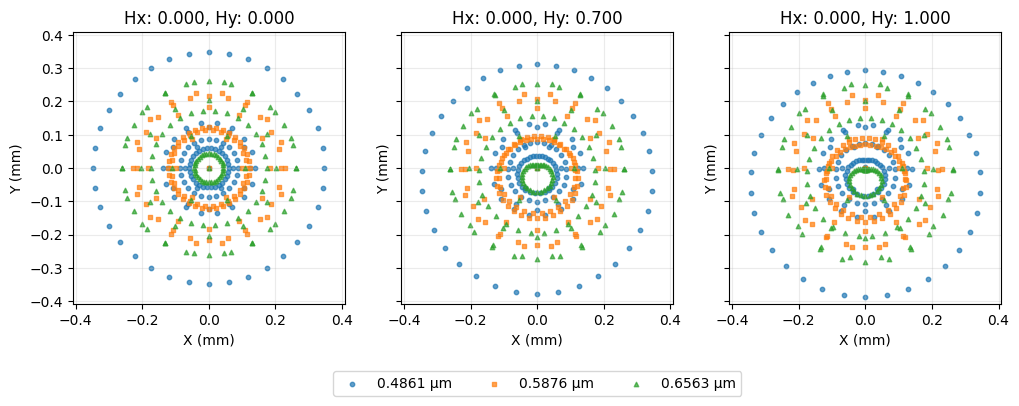

In [6]:
spot_dls = analysis.SpotDiagram(lens_dls)
_ = spot_dls.view()

## 9. A global-search example

For problems with many local minima (e.g., starting a design from scratch), a global method can escape basins that gradient methods get stuck in. The trade-off is compute time — global methods typically need many more function evaluations.

> **Note:** Global methods ignore variable bounds set via `min_val`/`max_val` unless those bounds are explicitly passed as SciPy-compatible `bounds`. For global searches, always set sensible bounds on every variable.

In [7]:
# Differential Evolution (global) on a fresh copy
# We reduce the variable count to keep runtime manageable.
# workers=1 disables multiprocessing (required in notebook / spawn environments).
lens_de = copy.deepcopy(lens_start)
problem_de = OptimizationProblem()

problem_de.add_operand('f2', target=150, weight=1, input_data={'optic': lens_de})
problem_de.add_operand(
    'rms_spot_size', target=0, weight=1,
    input_data={'optic': lens_de, 'surface_number': -1,
                'Hx': 0, 'Hy': 0, 'num_rays': 3,
                'wavelength': 0.5876, 'distribution': 'hexapolar'}
)

problem_de.add_variable(lens_de, 'radius', surface_number=1, min_val=20, max_val=200)
problem_de.add_variable(lens_de, 'radius', surface_number=3, min_val=-300, max_val=-20)

result_de = minimize(problem_de, 'differential_evolution', workers=1, maxiter=200)
print(result_de)

c:\Users\kdani\Documents\Python_Scripts\optiland\.venv\Lib\site-packages\IPython\core\interactiveshell.py:3577: UserWarning: Method 'differential_evolution' is a global solver; variable bounds may be ignored by the underlying SciPy algorithm.
  exec(code_obj, self.user_global_ns, self.user_ns)


Optimization started — initial merit = 3553.33
  iter     1 | merit = 33.6155
  iter     2 | merit = 33.6155
Optimization ended  — final merit = 26.2274  (+99.26%)  [callback function requested stop early]
OptimizationResult(x=array([-0.28112402, -4.        ]), success=False, status='callback function requested stop early', value=26.227412449563186, initial_value=3553.3263292851743, improvement_pct=99.26189125289714, iterations=2, n_value_evals=156, n_jac_evals=0, wall_time_s=0.30911220000416506, history=None, backend='numpy', method='differential_evolution', resolved_from=None, multipliers=None, active_set=None, constraint_report=None, max_constraint_violation=None, grad_norm=None, lambda_final=None, cond_estimate=None)


## 10. Decision guide

Use this checklist to pick a method:

1. **Default choice → `'dls'`.**  
   Classical lens design with residual operands (spot, OPD, Seidel, focal-length constraints) converges fastest with Damped Least Squares.

2. **Need inequality constraints or complex bounds → `'slsqp'` or `'trust-constr'`.**  
   SciPy's constrained optimizers handle `>=` and `<=` constraints natively.

3. **GPU / differentiable pipeline → `'adam'`.**  
   If you are using the Torch backend and your operands are differentiable end-to-end, Adam exploits automatic differentiation.

4. **Unknown starting point / many local minima → global method.**  
   Run `'differential_evolution'` or `'dual_annealing'` first to find a good basin, then refine with `'dls'`.

5. **Unsure → `'auto'`.**  
   Optiland inspects the problem and picks for you. Check `result.method` afterward to learn what it chose.

**Next:** [Tutorial 3c — Stepped Optimization & DLS/LM](Tutorial_3c_Stepped_Optimization_and_DLS.ipynb) shows how to tune the DLS controller and stopping criteria.